Dataset Loaded Successfully
Shape: (10000, 8)
   Unnamed: 0  Transaction_ID  Company_ID  Product_ID  Quantity  \
0         0.0             1.0        88.0         6.0       NaN   
1         1.0             2.0        29.0        19.0      16.0   
2         2.0             NaN        28.0        18.0       6.0   
3         3.0             4.0        85.0        12.0      12.0   
4         4.0             5.0        47.0         3.0       8.0   

  Transaction_Date  Product_Price  Total_Cost  
0       2024/03/26  194379.147964   1075200.0  
1    July 09, 2024   97930.993380   1428000.0  
2       04/13/2024  126095.547778    940800.0  
3       09-06-2023            NaN   1008000.0  
4       07/06/2021   99575.609634    705600.0  

Feature Engineering Completed

Monthly Aggregated Sales:
   Transaction_Date       Revenue
55       2024-08-31  2.288366e+08
56       2024-09-30  2.297294e+08
57       2024-10-31  2.028481e+08
58       2024-11-30  2.015988e+07
59       2024-12-31  7.196893e+06


C:\Users\lawre\AppData\Local\Temp\ipykernel_21892\1691314000.py:58: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Transaction_Date', freq='M')


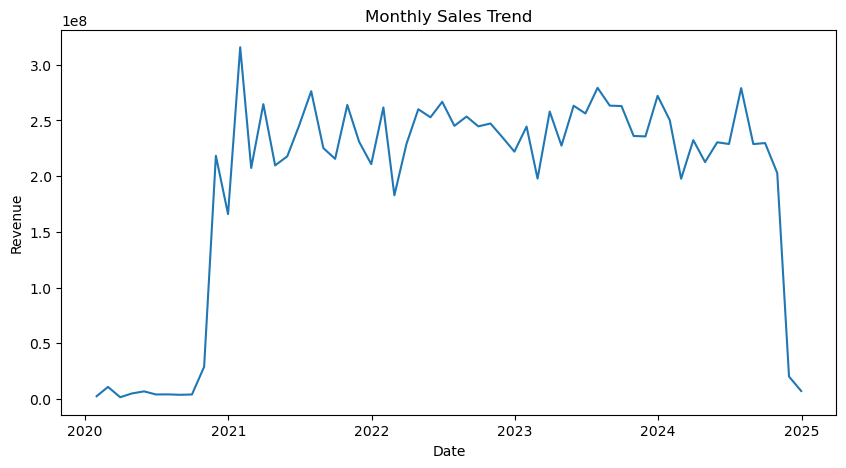

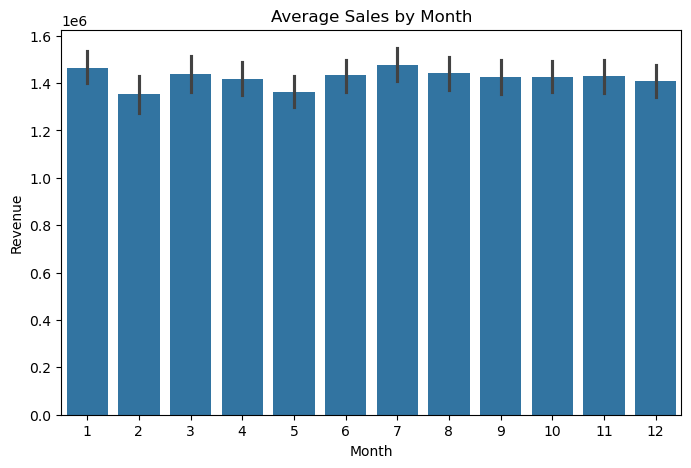

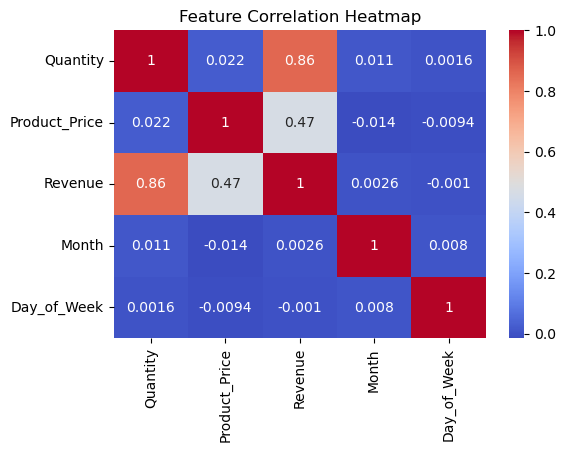


Model Training Complete

Model Evaluation
Mean Absolute Error: 147518703.92433366

3-MONTH SALES FORECAST
2025-01-31   -8.521180e+06
2025-02-28    2.296996e+06
2025-03-31   -5.148760e+06
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\lawre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lawre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lawre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lawre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lawre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  

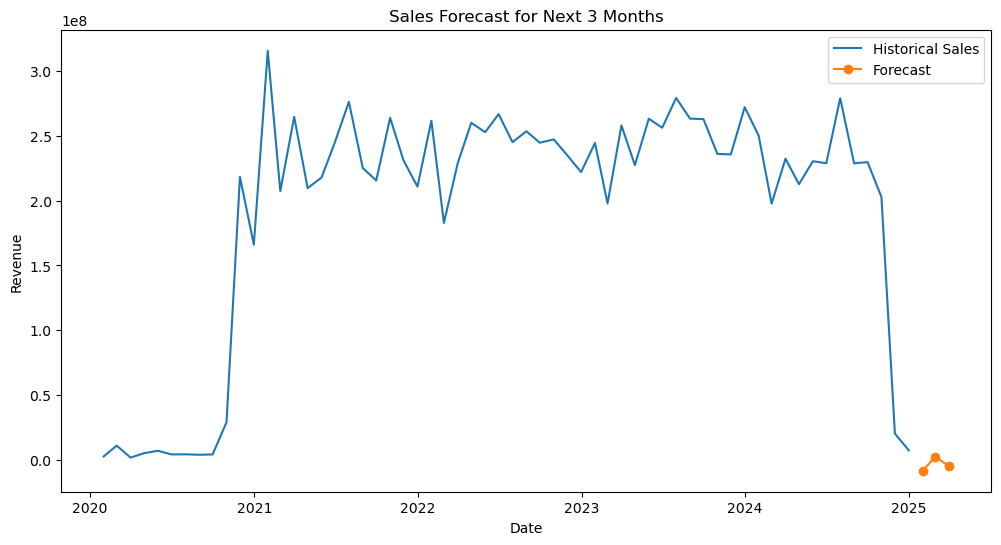


Dataset saved to: C:\Users\lawre\Downloads\feature_engineered_transactions.csv

ANALYSIS SUMMARY REPORT

1. Data preprocessing converted transaction dates and sorted records.

2. Feature engineering generated:
   - Year
   - Month
   - Day of Week
   - Revenue
   - Average Product Price

3. Exploratory Data Analysis identified:
   - Monthly revenue trends
   - Seasonal patterns
   - Relationships between variables.

4. A time-series forecasting model (ARIMA) was applied to predict future sales.

5. The model generated sales predictions for the next three months,
   which can help guide inventory planning, budgeting, and sales strategy.



In [5]:
# ============================================
# FINMARK SALES FORECASTING – COMPLETE REPORT
# Machine Learning & Data Analysis Workflow
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# -------------------------------
# 1. LOAD DATASET
# -------------------------------

file_path = r"C:\Users\lawre\Downloads\transactions_data (2).csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.head())


# -------------------------------
# 2. DATA PREPROCESSING
# -------------------------------

# Convert Date Column
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='mixed')

# Sort by date
df = df.sort_values("Transaction_Date")


# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------

df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day_of_Week'] = df['Transaction_Date'].dt.dayofweek

# Revenue feature
df['Revenue'] = df['Quantity'] * df['Product_Price']

# Average product price
df['Avg_Product_Price'] = df.groupby('Product_ID')['Product_Price'].transform('mean')

print("\nFeature Engineering Completed")


# -------------------------------
# 4. MONTHLY SALES AGGREGATION
# -------------------------------

monthly_sales = df.groupby(
    pd.Grouper(key='Transaction_Date', freq='M')
)['Revenue'].sum().reset_index()

# Remove incomplete or zero months
monthly_sales = monthly_sales[monthly_sales['Revenue'] > 0]

print("\nMonthly Aggregated Sales:")
print(monthly_sales.tail())


# -------------------------------
# 5. EXPLORATORY DATA ANALYSIS
# -------------------------------

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Transaction_Date'], monthly_sales['Revenue'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


plt.figure(figsize=(8,5))
sns.barplot(x='Month', y='Revenue', data=df)
plt.title("Average Sales by Month")
plt.show()


corr = df[['Quantity','Product_Price','Revenue','Month','Day_of_Week']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# -------------------------------
# 6. PREPARE DATA FOR FORECASTING
# -------------------------------

monthly_sales = monthly_sales.set_index('Transaction_Date')

train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]


# -------------------------------
# 7. BUILD ARIMA FORECAST MODEL
# -------------------------------

model = ARIMA(train['Revenue'], order=(1,1,1))
model_fit = model.fit()

print("\nModel Training Complete")


# -------------------------------
# 8. MODEL VALIDATION
# -------------------------------

predictions = model_fit.forecast(steps=3)

mae = mean_absolute_error(test['Revenue'], predictions)

print("\nModel Evaluation")
print("Mean Absolute Error:", mae)


# -------------------------------
# 9. FORECAST NEXT 3 MONTHS
# -------------------------------

final_model = ARIMA(monthly_sales['Revenue'], order=(1,1,1))
final_model_fit = final_model.fit()

forecast = final_model_fit.forecast(steps=3)

print("\n==============================")
print("3-MONTH SALES FORECAST")
print("==============================")
print(forecast)


# -------------------------------
# 10. FORECAST VISUALIZATION
# -------------------------------

future_dates = pd.date_range(
    monthly_sales.index[-1],
    periods=4,
    freq='M'
)[1:]

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales['Revenue'],
         label="Historical Sales")

plt.plot(future_dates,
         forecast,
         marker='o',
         label="Forecast")

plt.title("Sales Forecast for Next 3 Months")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()


# -------------------------------
# 11. SAVE UPDATED DATASET
# -------------------------------

save_path = r"C:\Users\lawre\Downloads\feature_engineered_transactions.csv"

df.to_csv(save_path, index=False)

print("\nDataset saved to:", save_path)


# -------------------------------
# 12. SUMMARY REPORT
# -------------------------------

print("\n==============================")
print("ANALYSIS SUMMARY REPORT")
print("==============================")

print("""
1. Data preprocessing converted transaction dates and sorted records.

2. Feature engineering generated:
   - Year
   - Month
   - Day of Week
   - Revenue
   - Average Product Price

3. Exploratory Data Analysis identified:
   - Monthly revenue trends
   - Seasonal patterns
   - Relationships between variables.

4. A time-series forecasting model (ARIMA) was applied to predict future sales.

5. The model generated sales predictions for the next three months,
   which can help guide inventory planning, budgeting, and sales strategy.
""")